In [1]:
import gc
import inspect
import json
import math
import sys
import time
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parents[1]
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import clear_output, display
from tqdm.auto import tqdm
from transformers import GPT2LMHeadModel, GPT2TokenizerFast, Trainer, TrainerCallback, TrainingArguments, set_seed

from src.sft import (
    SFTCollator,
    SFTDataPaths,
    SFTDatasetBuilder,
    SFTExampleConfig,
    SFTSchema,
    SIDMapping,
    evaluate_rankings,
    examples_to_dataset,
    generate_recommendations,
)

set_seed(42)
torch.backends.cuda.matmul.allow_tf32 = True
assert torch.cuda.is_available(), "This notebook expects CUDA to be available."

RUN_NAME = "sft_gpt2_medium_plus_plus_plus_monitor"
SID_PATH = ROOT / "data" / "processed" / "SIDs_V1.npy"
CPT_CHECKPOINT = ROOT / "data" / "processed" / "artifacts" / "CPT_user_behavior_V1" / "cpt_gpt2-medium_v1_plus_plus_plus" / "checkpoint-1000"
OUTPUT_DIR = ROOT / "data" / "processed" / "artifacts" / "SFT" / RUN_NAME
LOG_DIR = OUTPUT_DIR / "logs"
PRED_DIR = OUTPUT_DIR / "predictions"
LOG_CSV = LOG_DIR / "epoch_metrics.csv"
LOG_JSON = LOG_DIR / "epoch_metrics.json"
PLOT_PATH = LOG_DIR / "epoch_curves.png"
SUMMARY_PATH = ROOT / "reports" / f"{RUN_NAME}_summary.json"

MAX_SFT_EPOCHS = 3
EARLY_STOP_METRIC = "recall@10"
EARLY_STOP_PATIENCE = 2
MIN_DELTA = 1e-4

TRAIN_EXAMPLES_PER_USER = 5
MAX_HISTORY_EVENTS = 100
MAX_LENGTH = 512

TARGET_MEMORY_GB = 13.5
MAX_SAFE_MEMORY_GB = 14.2
MAX_MICRO_BATCH_TO_TRY = 16
RUN_MEMORY_CALIBRATION = True
MICRO_BATCH_SIZE = None
EFFECTIVE_BATCH_SIZE = 32

USE_BF16 = torch.cuda.is_bf16_supported()
USE_FP16 = not USE_BF16
USE_GRADIENT_CHECKPOINTING = False

LOSS_EVAL_MAX_EXAMPLES = 512
EPOCH_RECSYS_EVAL_MAX_USERS = 1024
FINAL_RECSYS_EVAL_MAX_USERS = None
RECSYS_BEAMS = 10
RECSYS_TOP_K = 20

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)

{
    "device": "cuda",
    "cpt_checkpoint": str(CPT_CHECKPOINT),
    "output_dir": str(OUTPUT_DIR),
    "bf16": USE_BF16,
    "target_memory_gb": TARGET_MEMORY_GB,
}

{'gpu': 'NVIDIA GeForce RTX 4080 SUPER',
 'cpt_checkpoint': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\CPT_user_behavior_V1\\cpt_gpt2-medium_v1_plus_plus_plus\\checkpoint-1000',
 'output_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\SFT\\sft_gpt2_medium_plus_plus_plus_monitor',
 'bf16': True,
 'target_vram_gb': 13.5}

In [2]:
sids = np.load(SID_PATH)
tokenizer = GPT2TokenizerFast.from_pretrained(CPT_CHECKPOINT)
schema = SFTSchema(n_sid_levels=sids.shape[1])

builder = SFTDatasetBuilder(
    paths=SFTDataPaths(
        processed_dir=ROOT / "data" / "processed",
        raw_ml1m_dir=ROOT / "data" / "raw" / "ml-1m",
    ),
    schema=schema,
    config=SFTExampleConfig(
        max_history_events=MAX_HISTORY_EVENTS,
        min_history_events=3,
        max_length=MAX_LENGTH,
        include_user_features=True,
        include_ratings=True,
        train_examples_per_user=TRAIN_EXAMPLES_PER_USER,
        max_users=None,
    ),
)

train, val, test, users = builder.load_tables()
train_examples = builder.build_train_examples(sids=sids, tokenizer=tokenizer, train=train, users=users)
val_examples = builder.build_eval_examples("val", sids=sids, tokenizer=tokenizer, train=train, val=val, test=test, users=users)
test_examples = builder.build_eval_examples("test", sids=sids, tokenizer=tokenizer, train=train, val=val, test=test, users=users)

for example in train_examples[:512] + val_examples[:512] + test_examples[:512]:
    assert example["target_item_idx"] not in example["history_item_idx"]
    assert len(example["target_sid"]) == sids.shape[1]
    assert len(example["input_ids"]) == len(example["labels"])
    assert any(label != -100 for label in example["labels"])
    first_target = next(i for i, label in enumerate(example["labels"]) if label != -100)
    assert first_target == example["prompt_length"]
    assert all(label == -100 for label in example["labels"][:first_target])

train_ds = examples_to_dataset(train_examples)
val_ds = examples_to_dataset(val_examples)
test_ds = examples_to_dataset(test_examples)
loss_eval_ds = val_ds.select(range(min(LOSS_EVAL_MAX_EXAMPLES, len(val_ds))))
sid_mapping = SIDMapping.from_sids(sids, interactions=train)

epoch_recsys_examples = val_examples[:EPOCH_RECSYS_EVAL_MAX_USERS]
final_val_examples = val_examples if FINAL_RECSYS_EVAL_MAX_USERS is None else val_examples[:FINAL_RECSYS_EVAL_MAX_USERS]
final_test_examples = test_examples if FINAL_RECSYS_EVAL_MAX_USERS is None else test_examples[:FINAL_RECSYS_EVAL_MAX_USERS]

{
    "train_examples": len(train_examples),
    "val_examples": len(val_examples),
    "test_examples": len(test_examples),
    "epoch_recsys_examples": len(epoch_recsys_examples),
    "sid_uniqueness": sid_mapping.uniqueness,
    "collision_buckets": sid_mapping.n_collision_buckets,
    "collision_excess": sid_mapping.n_collision_excess,
    "max_train_len": max(len(x["input_ids"]) for x in train_examples),
}

{'train_examples': 30200,
 'val_examples': 6040,
 'test_examples': 6040,
 'epoch_recsys_examples': 1024,
 'sid_uniqueness': 0.9495412844036697,
 'collision_buckets': 98,
 'collision_excess': 187,
 'max_train_len': 509}

In [3]:
collator = SFTCollator(tokenizer)

def load_sft_model():
    model = GPT2LMHeadModel.from_pretrained(CPT_CHECKPOINT)
    model.resize_token_embeddings(len(tokenizer))
    model.config.eos_token_id = tokenizer.eos_token_id
    model.config.bos_token_id = tokenizer.bos_token_id
    model.config.pad_token_id = tokenizer.pad_token_id
    if USE_GRADIENT_CHECKPOINTING:
        model.config.use_cache = False
        model.gradient_checkpointing_enable()
    return model

def tensor_batch_to_device(batch, device):
    return {key: value.to(device) for key, value in batch.items()}

def memory_gb(kind="reserved"):
    if not torch.cuda.is_available():
        return 0.0
    value = torch.cuda.max_memory_reserved() if kind == "reserved" else torch.cuda.max_memory_allocated()
    return value / 1024**3

def calibrate_micro_batch_size():
    lengths = [len(row["input_ids"]) for row in train_examples]
    longest = train_examples[int(np.argmax(lengths))]
    rows = []
    selected = 1

    for batch_size in range(1, MAX_MICRO_BATCH_TO_TRY + 1):
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        model = load_sft_model().to("cuda")
        model.train()
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
        batch = collator([longest] * batch_size)
        batch = tensor_batch_to_device(batch, "cuda")

        try:
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16 if USE_BF16 else torch.float16):
                loss = model(**batch).loss
            loss.backward()
            optimizer.step()
            reserved = memory_gb("reserved")
            allocated = memory_gb("allocated")
            rows.append({"micro_batch": batch_size, "reserved_gb": reserved, "allocated_gb": allocated, "ok": True})
            if reserved <= MAX_SAFE_MEMORY_GB:
                selected = batch_size
            if reserved >= TARGET_MEMORY_GB:
                break
        except RuntimeError as exc:
            if "out of memory" not in str(exc).lower():
                raise
            rows.append({"micro_batch": batch_size, "reserved_gb": None, "allocated_gb": None, "ok": False})
            break
        finally:
            del model, optimizer, batch
            gc.collect()
            torch.cuda.empty_cache()

    return selected, pd.DataFrame(rows)

if RUN_MEMORY_CALIBRATION:
    MICRO_BATCH_SIZE, memory_table = calibrate_micro_batch_size()
else:
    MICRO_BATCH_SIZE = 2
    memory_table = pd.DataFrame([{"micro_batch": MICRO_BATCH_SIZE, "reserved_gb": None, "allocated_gb": None, "ok": True}])

GRADIENT_ACCUMULATION_STEPS = max(1, math.ceil(EFFECTIVE_BATCH_SIZE / MICRO_BATCH_SIZE))
display(memory_table)
{
    "selected_micro_batch_size": MICRO_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "approx_effective_batch": MICRO_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS,
}

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

,micro_batch,reserved_gb,allocated_gb,ok
0,1,6.812500,6.636609,True
1,2,7.621094,7.159870,True
2,3,8.800781,8.436015,True
3,4,10.126953,9.670629,True
4,5,11.535156,10.923289,True
5,6,12.847656,12.182459,True
6,7,14.265625,13.463373,True


{'selected_micro_batch_size': 6,
 'gradient_accumulation_steps': 6,
 'approx_effective_batch': 36}

In [4]:
def training_args_kwargs():
    kwargs = {
        "output_dir": str(OUTPUT_DIR),
        "num_train_epochs": MAX_SFT_EPOCHS,
        "learning_rate": 1e-5,
        "warmup_steps": 50,
        "weight_decay": 0.01,
        "per_device_train_batch_size": MICRO_BATCH_SIZE,
        "per_device_eval_batch_size": MICRO_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "logging_steps": 50,
        "save_strategy": "no",
        "eval_strategy": "no",
        "fp16": USE_FP16,
        "bf16": USE_BF16,
        "gradient_checkpointing": USE_GRADIENT_CHECKPOINTING,
        "report_to": "none",
        "remove_unused_columns": False,
        "disable_tqdm": False,
        "optim": "adamw_torch",
    }
    params = inspect.signature(TrainingArguments).parameters
    return {key: value for key, value in kwargs.items() if key in params}

@torch.no_grad()
def compute_teacher_forcing_loss(model, dataset):
    loader = torch.utils.data.DataLoader(dataset, batch_size=MICRO_BATCH_SIZE, shuffle=False, collate_fn=collator)
    model.eval()
    total_loss = 0.0
    total_rows = 0
    device = next(model.parameters()).device
    for batch in loader:
        batch = tensor_batch_to_device(batch, device)
        output = model(**batch)
        rows = int(batch["input_ids"].shape[0])
        total_loss += float(output.loss.detach().cpu()) * rows
        total_rows += rows
    return total_loss / max(total_rows, 1)

def run_recsys_eval(model, examples, desc):
    model.eval()
    records = []
    device = next(model.parameters()).device
    for example in tqdm(examples, desc=desc, leave=False):
        records.append(
            generate_recommendations(
                model=model,
                tokenizer=tokenizer,
                example=example,
                sid_mapping=sid_mapping,
                schema=schema,
                sids=sids,
                k=RECSYS_TOP_K,
                num_beams=RECSYS_BEAMS,
                constraint="trie",
                device=device,
            )
        )
    metrics = evaluate_rankings(records, k_values=(1, 5, 10, 20))
    return records, metrics

def compact_record(record):
    return {
        "user_id": record["user_id"],
        "target_item_idx": record["target_item_idx"],
        "target_sid": list(record["target_sid"]),
        "candidates": record["candidates"],
        "invalid_sid_count": record["invalid_sid_count"],
        "generated_sid_count": record["generated_sid_count"],
        "duplicate_count": record["duplicate_count"],
    }

def write_jsonl(path, records):
    with path.open("w", encoding="utf-8") as f:
        for record in records:
            f.write(json.dumps(compact_record(record), ensure_ascii=False) + "\n")

def save_epoch_logs(rows):
    df = pd.DataFrame(rows)
    df.to_csv(LOG_CSV, index=False)
    LOG_JSON.write_text(json.dumps(rows, indent=2, ensure_ascii=False), encoding="utf-8")
    return df

def plot_epoch_logs(rows):
    df = pd.DataFrame(rows)
    if df.empty:
        return None
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(df["epoch"], df["teacher_forcing_eval_loss"], marker="o")
    axes[0].set_title("Teacher-forcing loss")
    axes[0].set_xlabel("epoch")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(df["epoch"], df["recall@10"], marker="o", label="Recall@10")
    axes[1].plot(df["epoch"], df["ndcg@10"], marker="o", label="NDCG@10")
    axes[1].set_title("Recsys metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(df["epoch"], df["peak_memory_reserved_gb"], marker="o")
    axes[2].axhline(TARGET_MEMORY_GB, linestyle="--", color="tab:green", label="target")
    axes[2].axhline(MAX_SAFE_MEMORY_GB, linestyle="--", color="tab:red", label="safe max")
    axes[2].set_title("Peak reserved memory")
    axes[2].set_xlabel("epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOT_PATH, dpi=160)
    return fig

In [5]:
class EpochRecsysMonitorCallback(TrainerCallback):
    def __init__(self):
        self.rows = []
        self.best_metric = -float("inf")
        self.best_epoch = None
        self.best_model_dir = None
        self.bad_epochs = 0
        self.last_seen_epoch = 0

    def on_epoch_begin(self, args, state, control, **kwargs):
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
        return control

    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        epoch = int(round(float(state.epoch or 0)))
        if epoch <= self.last_seen_epoch:
            return control
        self.last_seen_epoch = epoch

        started = time.time()
        epoch_dir = OUTPUT_DIR / f"epoch-{epoch:02d}"
        epoch_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(epoch_dir)
        tokenizer.save_pretrained(epoch_dir)

        teacher_loss = compute_teacher_forcing_loss(model, loss_eval_ds)
        records, recsys = run_recsys_eval(model, epoch_recsys_examples, desc=f"epoch {epoch} recsys")
        write_jsonl(PRED_DIR / f"epoch-{epoch:02d}_val_probe_predictions.jsonl", records)

        last_train_loss = None
        for item in reversed(state.log_history):
            if "loss" in item:
                last_train_loss = item["loss"]
                break

        metric_value = float(recsys[EARLY_STOP_METRIC])
        improved = metric_value > self.best_metric + MIN_DELTA
        if improved:
            self.best_metric = metric_value
            self.best_epoch = epoch
            self.best_model_dir = str(epoch_dir)
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1

        row = {
            "epoch": epoch,
            "global_step": int(state.global_step),
            "train_loss_last": last_train_loss,
            "teacher_forcing_eval_loss": teacher_loss,
            "epoch_eval_seconds": time.time() - started,
            "peak_memory_reserved_gb": memory_gb("reserved"),
            "peak_memory_allocated_gb": memory_gb("allocated"),
            "best_epoch": self.best_epoch,
            "best_metric": self.best_metric,
            "bad_epochs": self.bad_epochs,
            **recsys,
        }
        self.rows.append(row)
        df = save_epoch_logs(self.rows)
        fig = plot_epoch_logs(self.rows)

        clear_output(wait=True)
        display(df)
        if fig is not None:
            display(fig)
            plt.close(fig)

        if self.bad_epochs >= EARLY_STOP_PATIENCE:
            print(f"Early stopping: {EARLY_STOP_METRIC} did not improve for {EARLY_STOP_PATIENCE} epochs.")
            control.should_training_stop = True

        model.train()
        return control

model = load_sft_model()
args = TrainingArguments(**training_args_kwargs())
monitor = EpochRecsysMonitorCallback()

trainer_kwargs = {
    "model": model,
    "args": args,
    "train_dataset": train_ds,
    "data_collator": collator,
    "callbacks": [monitor],
}
trainer_params = inspect.signature(Trainer).parameters
if "processing_class" in trainer_params:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Trainer(**trainer_kwargs)
trainer

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

,epoch,global_step,train_loss_last,teacher_forcing_eval_loss,epoch_eval_seconds,peak_vram_reserved_gb,peak_vram_allocated_gb,best_epoch,best_metric,bad_epochs,...,mrr@5,recall@10,ndcg@10,mrr@10,recall@20,ndcg@20,mrr@20,invalid_sid_rate,duplicate_rate,item_coverage
0,1,839,1.664357,1.387263,268.465321,14.414062,13.847288,1,0.036133,0,...,0.014339,0.036133,0.020416,0.015655,0.041016,0.021629,0.015976,0.0,0.0,248.0
1,2,1678,1.550690,1.337253,311.887049,14.437500,13.851322,1,0.036133,1,...,0.014339,0.033203,0.019375,0.015025,0.041016,0.021397,0.015606,0.0,0.0,275.0
2,3,2517,1.485380,1.321097,547.635777,14.437500,13.847516,3,0.038086,0,...,0.014974,0.038086,0.021124,0.015790,0.043945,0.022637,0.016221,0.0,0.0,271.0


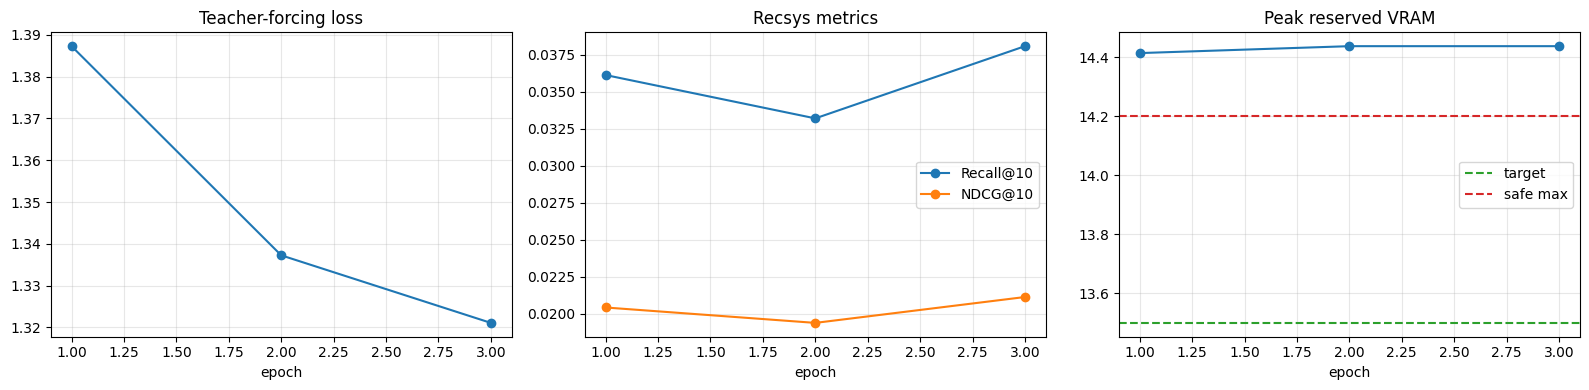

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_seconds': 5607.301095485687,
 'train_metrics': {'train_runtime': 5607.0004,
  'train_samples_per_second': 16.158,
  'train_steps_per_second': 0.449,
  'total_flos': 8.359375707645542e+16,
  'train_loss': 1.6423314579147927,
  'epoch': 3.0},
 'best_epoch': 3,
 'best_metric': 0.0380859375,
 'best_model_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\SFT\\sft_gpt2_medium_plus_plus_plus_monitor\\epoch-03',
 'final_model_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\SFT\\sft_gpt2_medium_plus_plus_plus_monitor\\final'}

In [6]:
started_at = time.time()
train_output = trainer.train()
train_seconds = time.time() - started_at

FINAL_MODEL_DIR = OUTPUT_DIR / "final"
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(FINAL_MODEL_DIR))
tokenizer.save_pretrained(FINAL_MODEL_DIR)

BEST_MODEL_DIR = Path(monitor.best_model_dir) if monitor.best_model_dir else FINAL_MODEL_DIR
{
    "train_seconds": train_seconds,
    "train_metrics": train_output.metrics,
    "best_epoch": monitor.best_epoch,
    "best_metric": monitor.best_metric,
    "best_model_dir": str(BEST_MODEL_DIR),
    "final_model_dir": str(FINAL_MODEL_DIR),
}

In [ ]:
RUN_FINAL_FULL_EVAL = True

if RUN_FINAL_FULL_EVAL:
    del trainer, model
    gc.collect()
    torch.cuda.empty_cache()

    eval_tokenizer = GPT2TokenizerFast.from_pretrained(BEST_MODEL_DIR)
    eval_model = GPT2LMHeadModel.from_pretrained(BEST_MODEL_DIR).to("cuda")
    eval_model.eval()

    def final_eval(split_name, examples):
        records = []
        t0 = time.time()
        for example in tqdm(examples, desc=f"final {split_name}"):
            records.append(
                generate_recommendations(
                    model=eval_model,
                    tokenizer=eval_tokenizer,
                    example=example,
                    sid_mapping=sid_mapping,
                    schema=schema,
                    sids=sids,
                    k=RECSYS_TOP_K,
                    num_beams=RECSYS_BEAMS,
                    constraint="trie",
                    device="cuda",
                )
            )
        metrics = evaluate_rankings(records, k_values=(1, 5, 10, 20))
        metrics["decode_seconds"] = time.time() - t0
        write_jsonl(PRED_DIR / f"final_{split_name}_predictions.jsonl", records)
        return metrics

    final_val_metrics = final_eval("val", final_val_examples)
    final_test_metrics = final_eval("test", final_test_examples)
else:
    final_val_metrics = None
    final_test_metrics = None

final_val_metrics, final_test_metrics

In [ ]:
summary = {
    "run_name": RUN_NAME,
    "model_family": "GPT-2 Medium",
    "cpt_checkpoint": str(CPT_CHECKPOINT),
    "output_dir": str(OUTPUT_DIR),
    "best_model_dir": str(BEST_MODEL_DIR),
    "final_model_dir": str(FINAL_MODEL_DIR),
    "sid_path": str(SID_PATH),
    "sid_shape": list(sids.shape),
    "train_examples": len(train_examples),
    "val_examples": len(val_examples),
    "test_examples": len(test_examples),
    "train_examples_per_user": TRAIN_EXAMPLES_PER_USER,
    "max_sft_epochs": MAX_SFT_EPOCHS,
    "early_stop_metric": EARLY_STOP_METRIC,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "micro_batch_size": MICRO_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "bf16": USE_BF16,
    "memory_calibration": memory_table.to_dict(orient="records"),
    "epoch_metrics": monitor.rows,
    "final_val_metrics": final_val_metrics,
    "final_test_metrics": final_test_metrics,
    "train_seconds": train_seconds,
    "train_output_metrics": train_output.metrics,
}

SUMMARY_PATH.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
summary

In [ ]:
logs = pd.read_csv(LOG_CSV) if LOG_CSV.exists() else pd.DataFrame(monitor.rows)
display(logs)
fig = plot_epoch_logs(logs.to_dict(orient="records"))
if fig is not None:
    display(fig)